# **Deep Learning**

In [1]:
#imports and setup
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [2]:
#Load MNIST and dataloaders
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST's known mean/std
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

print(len(train_dataset), len(test_dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 59.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.67MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.0MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.8MB/s]

60000 10000


In [17]:
#Model definition (MLP with BatchNorm + Dropout)
class MNIST_ANN(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()  # 28x28 image -> 784 flat vector since  layers below expect a flat list, not a grid

        self.fc1 = nn.Linear(784, 256)
        self.bn1 = nn.BatchNorm1d(256)

        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)

        self.fc3 = nn.Linear(128, 10)  # 10 output classes (digits 0-9)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=0.5) #randomly zero out 50% of the values passing through, during training

    def forward(self, x):
        x = self.flatten(x)

        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.fc3(x)  # no activation here — raw scores ("logits")
        return x

model = MNIST_ANN().to(device)
print(model)

MNIST_ANN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
)


In [19]:
#loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [20]:
#Training loop with train/validation split
from torch.utils.data import random_split

train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_subset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=256, shuffle=False)

def train_one_epoch():
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
    return total_loss / len(train_loader.dataset)

def evaluate(loader):
    model.eval()
    total_loss = 0
    correct = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1) #picks the index of the highest score
            correct += (preds == labels).sum().item() #counting how many predictions matched the true label.
    avg_loss = total_loss / len(loader.dataset)
    accuracy = correct / len(loader.dataset)
    return avg_loss, accuracy

In [21]:
#Run training and track losses
epochs = 15
train_losses, val_losses, val_accuracies = [], [], []

for epoch in range(epochs):
    train_loss = train_one_epoch()
    val_loss, val_acc = evaluate(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

Epoch 1/15 | Train Loss: 0.4647 | Val Loss: 0.1739 | Val Acc: 0.9462
Epoch 2/15 | Train Loss: 0.2443 | Val Loss: 0.1275 | Val Acc: 0.9610
Epoch 3/15 | Train Loss: 0.1931 | Val Loss: 0.1123 | Val Acc: 0.9650
Epoch 4/15 | Train Loss: 0.1741 | Val Loss: 0.0964 | Val Acc: 0.9697
Epoch 5/15 | Train Loss: 0.1523 | Val Loss: 0.0897 | Val Acc: 0.9717
Epoch 6/15 | Train Loss: 0.1420 | Val Loss: 0.0889 | Val Acc: 0.9733
Epoch 7/15 | Train Loss: 0.1331 | Val Loss: 0.0809 | Val Acc: 0.9755
Epoch 8/15 | Train Loss: 0.1221 | Val Loss: 0.0822 | Val Acc: 0.9772
Epoch 9/15 | Train Loss: 0.1157 | Val Loss: 0.0797 | Val Acc: 0.9767
Epoch 10/15 | Train Loss: 0.1141 | Val Loss: 0.0761 | Val Acc: 0.9793
Epoch 11/15 | Train Loss: 0.1066 | Val Loss: 0.0719 | Val Acc: 0.9792
Epoch 12/15 | Train Loss: 0.1004 | Val Loss: 0.0750 | Val Acc: 0.9790
Epoch 13/15 | Train Loss: 0.0963 | Val Loss: 0.0721 | Val Acc: 0.9788
Epoch 14/15 | Train Loss: 0.0942 | Val Loss: 0.0705 | Val Acc: 0.9798
Epoch 15/15 | Train Loss: 0.0

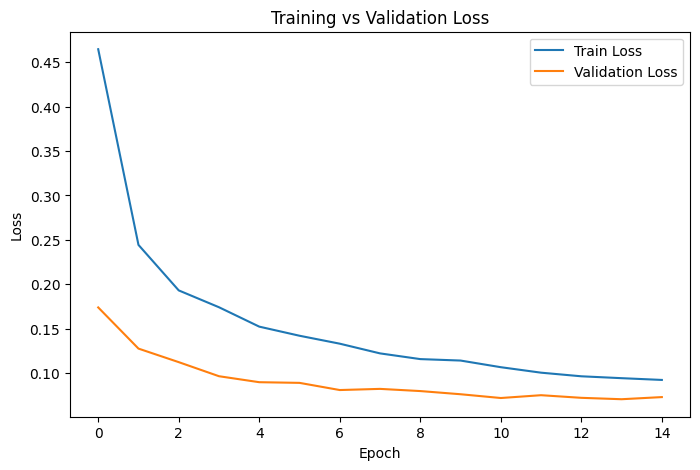

In [22]:
#Plot training vs validation loss
plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

In [23]:
#final test accuracy
test_loss, test_acc = evaluate(test_loader)
print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")

Test Loss: 0.0659 | Test Accuracy: 0.9801


In [24]:
#comparison with logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np

# Flatten data for sklearn
X_train = train_dataset.data.numpy().reshape(len(train_dataset), -1) / 255.0
y_train = train_dataset.targets.numpy()
X_test = test_dataset.data.numpy().reshape(len(test_dataset), -1) / 255.0
y_test = test_dataset.targets.numpy()

logreg = LogisticRegression(max_iter=200)
logreg.fit(X_train, y_train)
logreg_preds = logreg.predict(X_test)
logreg_acc = accuracy_score(y_test, logreg_preds)

print(f"Logistic Regression Test Accuracy: {logreg_acc:.4f}")
print(f"ANN Test Accuracy: {test_acc:.4f}")

Logistic Regression Test Accuracy: 0.9265
ANN Test Accuracy: 0.9801


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Final Summary

An Artificial Neural Network (ANN) was implemented in PyTorch to classify the 10 MNIST digit classes. The model consisted of two hidden layers with 256 and 128 neurons, respectively, using ReLU activation, Batch Normalization, and Dropout for regularization. The initial model used a dropout rate of **0.3** and achieved a test accuracy of **98.18%**.

To investigate the effect of stronger regularization, the dropout rate was increased from **0.3 to 0.5**. The higher dropout rate produced a more stable training/validation loss curve with less obvious overfitting, although the final test accuracy decreased slightly to **98.01%**. This shows that stronger regularization does not necessarily lead to better test performance.

For comparison, a Logistic Regression model was trained on the same MNIST dataset and achieved a test accuracy of **92.65%**, compared with **98.01%** for the final ANN. The ANN therefore performed substantially better because its multiple layers and nonlinear ReLU activations allow it to learn more complex patterns than the linear Logistic Regression model.

Overall, the ANN demonstrated strong performance on MNIST, while the experiments with different dropout rates showed how regularization affects the model's learning behavior and generalization.
